# Grayscale classification with Variopinta

Download [Fashion-MNIST](https://github.com/zalandoresearch/fashion-mnist), preview grayscale augmentations, and train a small PyTorch classifier.

Run this notebook in a Python 3.12 or 3.13 kernel with Variopinta 0.5.0 or newer. The install cell uses pip; torchvision downloads about **30 MB** once and caches it. The dataset contains 60,000 training and 10,000 test images, each 28 × 28 pixels with one of ten clothing labels.

Training runs for three epochs on CUDA when available, otherwise CPU.

Saved outputs were generated with the local grayscale development build; the pip install cell was skipped.

In [ ]:
%pip install -q --upgrade "variopinta>=0.5.0" torch torchvision numpy matplotlib

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import variopinta as vp
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import FashionMNIST

SEED, BATCH_SIZE, EPOCHS = 42, 128, 3
CACHE = Path.home() / ".cache" / "variopinta-fashion-mnist"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
plt.rcParams.update({"figure.dpi": 90, "axes.titlesize": 10})
print("Training device:", DEVICE)

Training device: cpu


## Download the images

Torchvision returns grayscale PIL images. `np.asarray` exposes each image as an HW `uint8` array, which Variopinta accepts directly.

In [3]:
train_data = FashionMNIST(CACHE, train=True, download=True)
test_data = FashionMNIST(CACHE, train=False, download=True)
class_names = train_data.classes
image = np.asarray(train_data[0][0])
assert image.shape == (28, 28) and image.dtype == np.uint8
print(f"{len(train_data):,} training · {len(test_data):,} test images")
print("Input:", image.shape, image.dtype)

60,000 training · 10,000 test images
Input: (28, 28) uint8


## Preview and replay augmentations

Pad by two pixels, crop back to 28 × 28, and optionally flip horizontally. These modest changes preserve the clothing category. The output keeps the input's HW shape.

An explicit key lets us replay an augmentation with the same input, pipeline, seed, build, and environment.

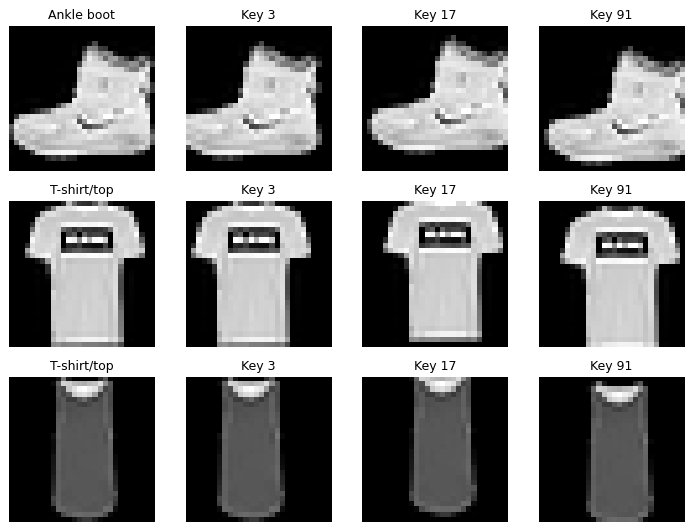

In [4]:
augmentations = [
    vp.PadIfNeeded(min_height=32, min_width=32, fill=0),
    vp.RandomCrop(28, 28),
    vp.HorizontalFlip(p=0.5),
]
array_target = vp.Image(carrier=vp.Array(), outputs=vp.ReturnArray(name="array"), name="image")
preview = vp.Pipeline(augmentations, seed=SEED, targets=(array_target,)).compile()

fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for row, index in enumerate((0, 1, 2)):
    pil_image, label = train_data[index]
    image = np.asarray(pil_image)
    panels = [(image, class_names[label])]
    for key in (3, 17, 91):
        augmented = preview(image=array_target.bind(image), key=key).image.array
        panels.append((augmented, f"Key {key}"))
    replayed = preview(image=array_target.bind(image), key=3).image.array
    assert replayed.shape == (28, 28) and replayed.dtype == np.uint8
    assert np.array_equal(panels[1][0], replayed)
    for ax, (pixels, title) in zip(axes[row], panels, strict=True):
        ax.imshow(pixels, cmap="gray", vmin=0, vmax=255)
        ax.set_title(title)
        ax.axis("off")
fig.tight_layout()
plt.show()

## Deliver single-channel training tensors

Scalar `mean=0.5` and `std=0.5` map pixels from [0, 255] to [-1, 1]. `ReturnTensor` produces contiguous float32 tensors shaped `(1, 28, 28)`.

The Dataset adapter calls the compiled pipeline. Training keys combine epoch and sample index; test inputs receive only normalization. The loaders use `num_workers=0`, so the adapter stays in this notebook and its epoch can be updated directly.

In [5]:
tensor_target = vp.Image(carrier=vp.Array(), outputs=vp.ReturnTensor(name="tensor"), name="image")
normalize = vp.Normalize(mean=0.5, std=0.5)
train_pipeline = vp.Pipeline(
    [*augmentations, normalize], seed=SEED, targets=(tensor_target,)
).compile()
test_pipeline = vp.Pipeline([normalize], targets=(tensor_target,)).compile()


class AugmentedFashion(Dataset):
    def __init__(self, data, pipeline):
        self.data, self.pipeline = data, pipeline
        self.target = pipeline.targets[0]
        self.epoch = 0

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        image, label = self.data[index]
        result = self.pipeline(
            image=self.target.bind(np.asarray(image)),
            key=self.epoch * len(self.data) + index,
        )
        return result.image.tensor, label


train_ds = AugmentedFashion(train_data, train_pipeline)
test_ds = AugmentedFashion(test_data, test_pipeline)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
x, label = train_ds[0]
assert x.shape == (1, 28, 28) and x.dtype == torch.float32 and x.is_contiguous()
print("Training tensor:", tuple(x.shape), x.dtype)

Training tensor: (1, 28, 28) torch.float32


## Train a small classifier

Two convolution layers learn directly from one-channel inputs. Train on the complete training split for three epochs, then evaluate the official test split once.

In [6]:
model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32 * 7 * 7, 64),
    nn.ReLU(),
    nn.Linear(64, 10),
).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    train_ds.epoch = epoch
    model.train()
    total_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = loss_fn(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(labels)
    print(f"Epoch {epoch + 1}/{EPOCHS} · train loss {total_loss / len(train_ds):.3f}")

Epoch 1/3 · train loss 0.758


Epoch 2/3 · train loss 0.524


Epoch 3/3 · train loss 0.452


## Evaluate and inspect predictions

Report test accuracy and show the first eight test predictions. Undo normalization for display. This small model illustrates the grayscale augmentation and training workflow; its accuracy is not a benchmark target.

Test accuracy: 85.1%


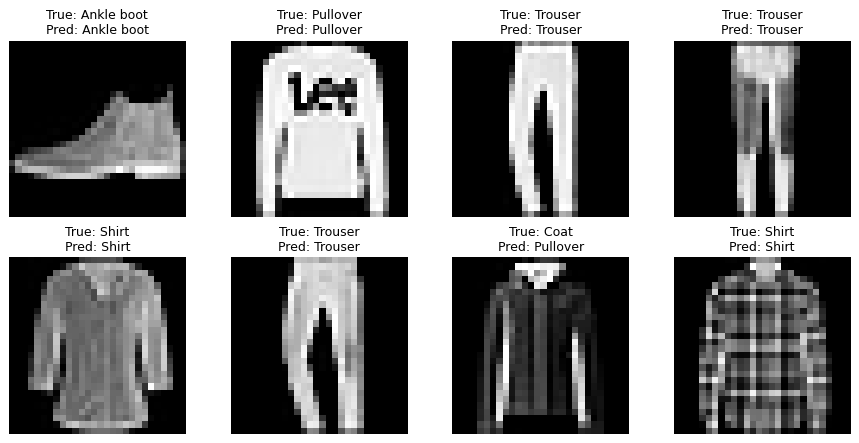

In [7]:
model.eval()
correct = 0
predictions = []
with torch.inference_mode():
    for images, labels in test_loader:
        predicted = model(images.to(DEVICE)).argmax(1).cpu()
        correct += (predicted == labels).sum().item()
        predictions.extend(predicted.tolist())
print(f"Test accuracy: {correct / len(test_ds):.1%}")

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for index, ax in enumerate(axes.flat):
    image, label = test_ds[index]
    prediction = predictions[index]
    ax.imshow(image[0].numpy() * 0.5 + 0.5, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"True: {class_names[label]}\nPred: {class_names[prediction]}")
    ax.axis("off")
fig.tight_layout()
plt.show()